In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
sns.set_palette('deep')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titleweight': 'bold',
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'grid.alpha': 0.25
})

In [ ]:
data_path = '../data/processed/fuel_prices_Indonesia.csv'
# Wenn vorhanden, können Sie hier Assignment_Data.csv verwenden:
# data_path = '../data/processed/Assignment_Data.csv'

df = pd.read_csv(data_path, parse_dates=['date'])
df = df.set_index('date').sort_index()

print('Datensatz:', data_path)
print('Zeilen, Spalten:', df.shape)
print('Spalten:', df.columns.tolist())
df.head()

         date    country region income_level subsidy_level  petrol_usd_liter  \
0  2020-01-06  Indonesia   Asia       Middle          High             0.540   
1  2020-01-13  Indonesia   Asia       Middle          High             0.555   
2  2020-01-20  Indonesia   Asia       Middle          High             0.542   
3  2020-01-27  Indonesia   Asia       Middle          High             0.551   
4  2020-02-03  Indonesia   Asia       Middle          High             0.549   

   diesel_usd_liter  lpg_usd_liter  brent_crude_usd  tax_percentage  
0             0.520          0.431            65.75            28.6  
1             0.530          0.432            65.54             3.0  
2             0.518          0.407            66.51            13.2  
3             0.527          0.411            68.79            25.3  
4             0.484          0.436            68.44             9.6  
(327, 10)
['date', 'country', 'region', 'income_level', 'subsidy_level', 'petrol_usd_liter', 'diese

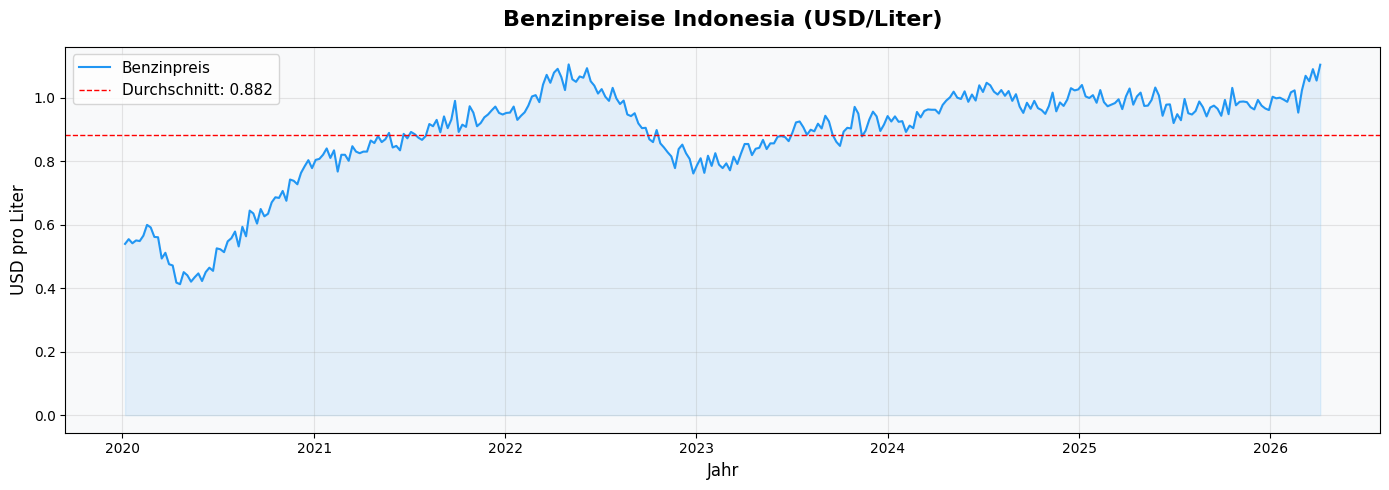

In [ ]:
y = df['petrol_usd_liter'].copy()
y = y.asfreq('W-MON')

print('Beschreibung der Zeitreihe y:')
print(y.describe())

fig, ax = plt.subplots()
sns.lineplot(x=y.index, y=y.values, ax=ax, color='#1976D2', linewidth=2.2)
ax.fill_between(y.index, y.values, alpha=0.15, color='#1976D2')
ax.axhline(y.mean(), color='#D32F2F', linestyle='--', linewidth=1.5,
           label=f'Mittelwert {y.mean():.3f} USD/Liter')
ax.set_title('Weekly Petrol Prices in Indonesia (USD per Liter)')
ax.set_xlabel('Datum')
ax.set_ylabel('Preis (USD/Liter)')
ax.legend()
ax.set_facecolor('#f9fbff')
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss


def stationarity_tests(series, title):
    print(f'--- {title} ---')
    adf = adfuller(series, autolag='AIC')
    print(f'ADF: stat={adf[0]:.4f}, p-value={adf[1]:.4f}, usedlag={adf[2]}')
    print('    Ergebnis: Stationär' if adf[1] < 0.05 else '    Ergebnis: Nicht stationär')
    kpss_res = kpss(series, regression='c', nlags='auto')
    print(f'KPSS: stat={kpss_res[0]:.4f}, p-value={kpss_res[1]:.4f}')
    print('    Ergebnis: H0 nicht verworfen → Stationär' if kpss_res[1] > 0.05 else '    Ergebnis: H0 verworfen → Nicht stationär')
    print()

stationarity_tests(y, 'Originalreihe y')

p-Wert: 0.3364
Nicht stationär → d=1


In [ ]:
y_diff = y.diff().dropna()
stationarity_tests(y_diff, 'Erste Differenz Δy')

fig, ax = plt.subplots()
sns.lineplot(x=y_diff.index, y=y_diff.values, ax=ax, color='#388E3C', linewidth=2)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Erste Differenz der Benzinpreise in Indonesien')
ax.set_xlabel('Datum')
ax.set_ylabel('ΔPreis (USD/Liter)')
plt.tight_layout()
plt.show()

p-Wert nach Differenzierung: 0.0011
Jetzt stationär (d=1)


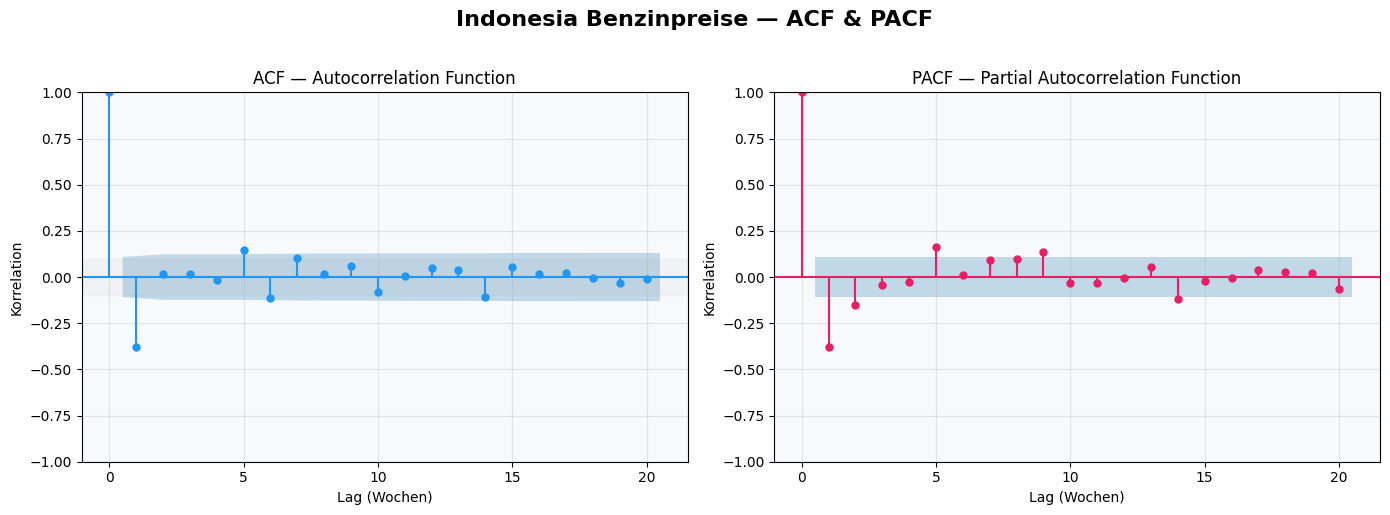

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(y_diff, lags=24, ax=axes[0], title='ACF — Autocorrelation Function', alpha=0.05,
         vlines_kwargs={'colors': '#1976D2'})
axes[0].axhspan(-0.1, 0.1, alpha=0.05, color='grey')
axes[0].set_xlabel('Lag (Wochen)')
axes[0].set_ylabel('Autokorrelation')

plot_pacf(y_diff, lags=24, ax=axes[1], title='PACF — Partial Autocorrelation Function', method='ywm', alpha=0.05,
          vlines_kwargs={'colors': '#D32F2F'})
axes[1].set_xlabel('Lag (Wochen)')
axes[1].set_ylabel('Partielle Autokorrelation')

fig.suptitle('Indonesia Benzinpreise — ACF & PACF der ersten Differenz', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

candidates = []
for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(y, order=(p, 1, q)).fit()
            candidates.append({
                'p': p,
                'd': 1,
                'q': q,
                'Model': f'ARIMA({p},1,{q})',
                'AIC': model.aic,
                'BIC': model.bic,
                'HQIC': model.hqic
            })
        except Exception:
            continue

results_df = pd.DataFrame(candidates).sort_values('AIC').reset_index(drop=True)
results_df['AIC'] = results_df['AIC'].round(2)
results_df['BIC'] = results_df['BIC'].round(2)
results_df['HQIC'] = results_df['HQIC'].round(2)
results_df.head(10)

/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodel

          Model      AIC      BIC
8  ARIMA(2,1,2) -1419.30 -1400.37
5  ARIMA(1,1,2) -1419.27 -1404.13
1  ARIMA(0,1,1) -1410.72 -1403.15
2  ARIMA(0,1,2) -1410.19 -1398.83
6  ARIMA(2,1,0) -1410.02 -1398.66
4  ARIMA(1,1,1) -1409.89 -1398.53
7  ARIMA(2,1,1) -1408.24 -1393.10
3  ARIMA(1,1,0) -1405.52 -1397.95
0  ARIMA(0,1,0) -1357.14 -1353.35


/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
styled = results_df.style \
    .background_gradient(subset=['AIC', 'BIC', 'HQIC'], cmap='RdYlGn_r') \
    .highlight_min(subset=['AIC'], color='#81C784') \
    .highlight_min(subset=['BIC'], color='#64B5F6') \
    .set_caption('ARIMA-Modellvergleich — Beste Kandidaten für Indonesien') \
    .format({'AIC': '{:.2f}', 'BIC': '{:.2f}', 'HQIC': '{:.2f}'})

styled

,Model,AIC,BIC
8,"ARIMA(2,1,2)",-1419.30,-1400.37
5,"ARIMA(1,1,2)",-1419.27,-1404.13
1,"ARIMA(0,1,1)",-1410.72,-1403.15
2,"ARIMA(0,1,2)",-1410.19,-1398.83
6,"ARIMA(2,1,0)",-1410.02,-1398.66
4,"ARIMA(1,1,1)",-1409.89,-1398.53
7,"ARIMA(2,1,1)",-1408.24,-1393.10
3,"ARIMA(1,1,0)",-1405.52,-1397.95
0,"ARIMA(0,1,0)",-1357.14,-1353.35


In [2]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

best_row = results_df.loc[results_df['AIC'].idxmin()]
best_order = (int(best_row['p']), int(best_row['d']), int(best_row['q']))
print('Bestes Modell nach AIC:', best_row['Model'])

model = ARIMA(y, order=best_order).fit()
residuals = model.resid

print(model.summary())

coeff_table = pd.DataFrame({
    'Parameter': model.params,
    'Std.Err.': model.bse,
    't-Wert': model.tvalues,
    'p-Wert': model.pvalues
})
coeff_table = coeff_table.round(4)
coeff_table

NameError: name 'results_df' is not defined

In [1]:
# Residuen und Modellvalidierung

print('Residual-Statistik:')
print(residuals.describe().round(4))

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

sns.lineplot(x=residuals.index, y=residuals.values, ax=axes[0], color='#6A1B9A')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Residuen des ARIMA-Modells')
axes[0].set_xlabel('Datum')
axes[0].set_ylabel('Residuen')

sns.histplot(residuals, kde=True, ax=axes[1], color='#0288D1', edgecolor='white')
axes[1].set_title('Residuenverteilung')
axes[1].set_xlabel('Residuen')

sm.qqplot(residuals, line='s', ax=axes[2], color='#D32F2F')
axes[2].set_title('QQ-Plot der Residuen')

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print('Ljung-Box-Test:')
print(lb)
print('\nResiduen sind unkorreliert' if lb['lb_pvalue'].iloc[-1] > 0.05 else '\nResiduen weisen Autokorrelation auf')

# Prognose für die nächsten 10 Perioden
forecast_steps = 10
forecast = model.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(x=y.index, y=y.values, ax=ax, label='Historische Werte', color='#1976D2')
ax.plot(forecast_df.index, forecast_df['mean'], color='#D32F2F', linewidth=2.2, label='Prognose (10 Perioden)')
ax.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='#F48FB1', alpha=0.35)
ax.set_title('ARIMA-Prognose für die nächsten 10 Wochen')
ax.set_xlabel('Datum')
ax.set_ylabel('USD pro Liter')
ax.legend()
plt.tight_layout()
plt.show()

forecast_df[['mean', 'mean_ci_lower', 'mean_ci_upper']].round(4)

Residual-Statistik:


NameError: name 'residuals' is not defined